# Hydro Generation in AIB Countries

This notebook quantifies hydro power generation across AIB (Association of Issuing Bodies) member countries using ENTSO-E actual generation data, and compares it to Guarantee of Origin (GO) issuance volumes. Only run-of-river and water reservoir generation are included, as these are fully eligible for GO issuance. Pumped storage is excluded since only the natural inflow portion qualifies for GOs.

In [5]:
aib_members = [
    'AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 
    'EE', 'ES', 'FI', 'FR', 'GE', 'GR', 'HR', 'HU', 'IE', 'IS', 
    'IT', 'LT', 'LU', 'LV', 'ME', 'MK', 'NL', 'NO', 'PT', 'RO', 
    'RS', 'SE', 'SI', 'SK', 'UA', 'XK'
]

aib_electricity_scheme_group = [
    'AT', 'BE', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
    'FR', 'GR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 
    'NL', 'NO', 'PT', 'RS', 'SE', 'SI', 'SK'
]

## Data Collection

We query the ENTSO-E hydro production curves from the database. Hydro generation is reported in three categories: run-of-river (RoR), water reservoir, and pumped storage. For GO comparison purposes, we use only RoR and reservoir generation as these are fully eligible for GO issuance. Pumped storage generation is excluded because only the natural inflow component qualifies — the pumped portion consumed grid electricity. Some countries (NO, SE, DK) report by bidding zone which must be summed to get a national total.

In [6]:
from kad_functions.sql_data import get_sql_query

hydro_query = """
SELECT CurveId, CurveName
FROM pub.dimMetadata
WHERE CurveName LIKE '%entso%'
  AND (CurveName LIKE '%reservoir%' OR CurveName LIKE '%ror%')
  AND IsDeprecated != 1
ORDER BY CreatedOn DESC;
"""

hydro_countries = get_sql_query(hydro_query)

display(hydro_countries)

,CurveId,CurveName
0,1500028461,ENTSOE-SERBIA-WATER-RESERVOIR-LEVEL
1,1500028460,ENTSOE-CROATIA-WATER-RESERVOIR-LEVEL
2,1500028459,ENTSOE-SLOVENIA-WATER-RESERVOIR-LEVEL
3,1500028458,ENTSOE-FRANCE-WATER-RESERVOIR-LEVEL
4,1500028457,ENTSOE-ITALY-NORTH-WATER-RESERVOIR-LEVEL
...,...,...
287,1000341692,ENTSOE-POWER-PRODUCTION-ACTUAL-HYDRO-RESERVOIR...
288,1000341693,ENTSOE-POWER-PRODUCTION-ACTUAL-HYDRO-RESERVOIR...
289,1000341694,ENTSOE-POWER-PRODUCTION-ACTUAL-HYDRO-RESERVOIR...
290,1000341695,ENTSOE-POWER-PRODUCTION-ACTUAL-HYDRO-RESERVOIR...


In [8]:
import pandas as pd

# Hardcoded ENTSO-E hydro production curve IDs per zone/country and generation type.
# Only run-of-river (ror) and reservoir are included (pumped storage excluded).
# Countries with bidding zones (NO, SE, DK) or TSO regions (DE) are listed by zone.
HYDRO_CURVE_IDS: dict[str, dict[str, int | None]] = {
    "AT": {
        "reservoir": 910000126,   # EntsoE_ActualGeneration_AT_WaterReservoir_PROD
        "ror": 910000124,         # EntsoE_ActualGeneration_AT_RoR_PROD
    },
    "BE": {
        "reservoir": 1500029392,  # ENTSOE-POWER-PRODUCTION-ACTUAL-BE-HYDRO-WATER-RESERVOIR-MW
        "ror": 910000143,         # EntsoE-ActualGeneration-BE-RoR
    },
    "CH": {
        "reservoir": 910000228,   # EntsoE-ActualGeneration-CH-WasterReservoir
        "ror": 910000227,         # EntsoE-ActualGeneration-CH-RoR
    },
    "CY": {
        "reservoir": None,
        "ror": None,
    },
    "CZ": {
        "reservoir": 910003000,   # ENTSOE_ActualGeneration_CZ_HYDRO-RESERVOIR__PROD
        "ror": 910002999,         # ENTSOE_ActualGeneration_CZ_HYDRO-RUN-OF-RIVER__PROD
    },
    "DE_AMP": {
        "reservoir": 910002168,   # EntsoE-ActualGeneration-DE-AMP-Reservoir-P
        "ror": 910002094,         # EntsoE-ActualGeneration-DE-AMP-RoR-P
    },
    "DE_TBW": {
        "reservoir": 910002137,   # EntsoE-ActualGeneration-DE-TBW-Reservoir-P
        "ror": 910002135,         # EntsoE-ActualGeneration-DE-TBW-RoR-P
    },
    "DE_TTG": {
        "reservoir": 910002117,   # EntsoE-ActualGeneration-DE-TTG-Reservoir-P
        "ror": 910002116,         # EntsoE-ActualGeneration-DE-TTG-RoR-P
    },
    "DE_50H": {
        "reservoir": None,        # No reservoir curve available
        "ror": 910002073,         # EntsoE-ActualGeneration-DE-50H-RoR
    },
    "DK1": {
        "reservoir": 1500028330,  # ENTSOE-POWER-PRODUCTION-ACTUAL-DK1-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500028329,        # ENTSOE-POWER-PRODUCTION-ACTUAL-DK1-HYDRO-ROR-POUNDAGE-MW
    },
    "DK2": {
        "reservoir": 1500028352,  # ENTSOE-POWER-PRODUCTION-ACTUAL-DK2-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500028351,        # ENTSOE-POWER-PRODUCTION-ACTUAL-DK2-HYDRO-ROR-POUNDAGE-MW
    },
    "EE": {
        "reservoir": 1500029053,  # ENTSOE-POWER-PRODUCTION-ACTUAL-EE-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500029052,        # ENTSOE-POWER-PRODUCTION-ACTUAL-EE-HYDRO-ROR-MW
    },
    "ES": {
        "reservoir": 910000216,   # EntsoE-ActualGeneration-ES-WaterReservoir
        "ror": 910000215,         # EntsoE-ActualGeneration-ES-RoR
    },
    "FI": {
        "reservoir": 1500028306,  # ENTSOE-POWER-PRODUCTION-ACTUAL-FI-HYDRO-WATER-RESERVOIR-MW
        "ror": 1000341691,        # ENTSOE-POWER-PRODUCTION-ACTUAL-HYDRO-RUN-OF-RIVER-FINGRID-MW-HOURS-1
    },
    "FR": {
        "reservoir": 910000240,   # EntsoE_ActualGeneration_FR_WaterReservoir_PROD
        "ror": 910000239,         # EntsoE_ActualGeneration_FR_RoR_PROD
    },
    "GR": {
        "reservoir": 910003085,   # ENTSOE_ActualGeneration_GR_HYDRO-RESERVOIR__PROD
        "ror": None,              # No RoR curve available
    },
    "HR": {
        "reservoir": 910004524,   # ENTSOE_ACTUAL-GENERATION_HR_HYDRO-RESERVOIR_PROD
        "ror": 910004523,         # ENTSOE_ACTUAL-GENERATION_HR_HYDRO-RUN-OF-RIVER_PROD
    },
    "HU": {
        "reservoir": 910003027,   # ENTSOE_ActualGeneration_HU_HYDRO-RESERVOIR__PROD
        "ror": 910003026,         # ENTSOE_ActualGeneration_HU_HYDRO-RUN-OF-RIVER__PROD
    },
    "IE": {
        "reservoir": None,        # No reservoir curve available
        "ror": 910002522,         # EntsoE-ActualGeneration-IE-RoR
    },
    "IS": {
        "reservoir": None,
        "ror": None,
    },
    "IT": {
        "reservoir": 1000300262,  # INCOMMODITIES-ENTSOE-IT-POWER-PRODUCTION-ACTUAL-HYDRO-RESERVOIR
        "ror": 1000300265,        # INCOMMODITIES-ENTSOE-IT-POWER-PRODUCTION-ACTUAL-HYDRO-RUN-OF-RIVER
    },
    "LT": {
        "reservoir": 1500029103,  # ENTSOE-POWER-PRODUCTION-ACTUAL-LT-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500029102,        # ENTSOE-POWER-PRODUCTION-ACTUAL-LT-HYDRO-ROR-MW
    },
    "LU": {
        "reservoir": None,
        "ror": None,
    },
    "LV": {
        "reservoir": 1500029075,  # ENTSOE-POWER-PRODUCTION-ACTUAL-LV-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500029074,        # ENTSOE-POWER-PRODUCTION-ACTUAL-LV-HYDRO-ROR-MW
    },
    "NL": {
        "reservoir": 1500029370,  # ENTSOE-POWER-PRODUCTION-ACTUAL-NL-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500029369,        # ENTSOE-POWER-PRODUCTION-ACTUAL-NL-HYDRO-ROR-MW
    },
    "NO1": {
        "reservoir": 1500026489,  # ENTSOE-POWER-PRODUCTION-ACTUAL-NO1-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026488,        # ENTSOE-POWER-PRODUCTION-ACTUAL-NO1-HYDRO-RUN-OF-RIVER-MW
    },
    "NO2": {
        "reservoir": 1500026531,  # ENTSOE-POWER-PRODUCTION-ACTUAL-NO2-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026530,        # ENTSOE-POWER-PRODUCTION-ACTUAL-NO2-HYDRO-RUN-OF-RIVER-MW
    },
    "NO3": {
        "reservoir": 1500026573,  # ENTSOE-POWER-PRODUCTION-ACTUAL-NO3-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026572,        # ENTSOE-POWER-PRODUCTION-ACTUAL-NO3-HYDRO-RUN-OF-RIVER-MW
    },
    "NO4": {
        "reservoir": 1500026615,  # ENTSOE-POWER-PRODUCTION-ACTUAL-NO4-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026614,        # ENTSOE-POWER-PRODUCTION-ACTUAL-NO4-HYDRO-RUN-OF-RIVER-MW
    },
    "NO5": {
        "reservoir": 1500026657,  # ENTSOE-POWER-PRODUCTION-ACTUAL-NO5-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026656,        # ENTSOE-POWER-PRODUCTION-ACTUAL-NO5-HYDRO-RUN-OF-RIVER-MW
    },
    "PT": {
        "reservoir": 910000340,   # EntsoE_ActualGeneration_PT_WaterReservoir_PROD
        "ror": 910000338,         # EntsoE_ActualGeneration_PT_RoR_PROD
    },
    "RS": {
        "reservoir": 910003068,   # ENTSOE_ActualGeneration_RS_HYDRO-RESERVOIR__PROD
        "ror": 910003067,         # ENTSOE_ActualGeneration_RS_HYDRO-RUN-OF-RIVER__PROD
    },
    "SE1": {
        "reservoir": 1500026314,  # ENTSOE-POWER-PRODUCTION-ACTUAL-SE1-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026313,        # ENTSOE-POWER-PRODUCTION-ACTUAL-SE1-HYDRO-RUN-OF-RIVER-MW
    },
    "SE2": {
        "reservoir": 1500026355,  # ENTSOE-POWER-PRODUCTION-ACTUAL-SE2-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026354,        # ENTSOE-POWER-PRODUCTION-ACTUAL-SE2-HYDRO-RUN-OF-RIVER-MW
    },
    "SE3": {
        "reservoir": 1500026397,  # ENTSOE-POWER-PRODUCTION-ACTUAL-SE3-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026396,        # ENTSOE-POWER-PRODUCTION-ACTUAL-SE3-HYDRO-RUN-OF-RIVER-MW
    },
    "SE4": {
        "reservoir": 1500026439,  # ENTSOE-POWER-PRODUCTION-ACTUAL-SE4-HYDRO-WATER-RESERVOIR-MW
        "ror": 1500026438,        # ENTSOE-POWER-PRODUCTION-ACTUAL-SE4-HYDRO-RUN-OF-RIVER-MW
    },
    "SI": {
        "reservoir": None,        # No reservoir curve available
        "ror": 910003058,         # ENTSOE_ActualGeneration_SI_HYDRO-RUN-OF-RIVER__PROD
    },
    "SK": {
        "reservoir": 910003015,   # ENTSOE_ActualGeneration_SK_HYDRO-RESERVOIR__PROD
        "ror": 910003014,         # ENTSOE_ActualGeneration_SK_HYDRO-RUN-OF-RIVER__PROD
    },
}

# Zone-to-country mapping for aggregation
zone_to_country = {
    'NO1': 'NO', 'NO2': 'NO', 'NO3': 'NO', 'NO4': 'NO', 'NO5': 'NO',
    'SE1': 'SE', 'SE2': 'SE', 'SE3': 'SE', 'SE4': 'SE',
    'DK1': 'DK', 'DK2': 'DK',
    'DE_AMP': 'DE', 'DE_TBW': 'DE', 'DE_TTG': 'DE', 'DE_50H': 'DE',
}

# Build hydro_curves DataFrame from the dictionary
records = []
for zone_or_country, types in HYDRO_CURVE_IDS.items():
    country = zone_to_country.get(zone_or_country, zone_or_country)
    zone = zone_or_country if zone_or_country in zone_to_country else None
    for gen_type, curve_id in types.items():
        if curve_id is None:
            continue
        records.append({
            'CurveId': curve_id,
            'CountryCode': country,
            'GenerationType': gen_type,
            'Zone': zone,
        })

hydro_curves = pd.DataFrame(records)

print(f"Selected {len(hydro_curves)} curves across {hydro_curves['CountryCode'].nunique()} countries")
print(f"\nCountries: {sorted(hydro_curves['CountryCode'].unique())}")
print(f"\nCurves per country and type:")
print(hydro_curves.groupby(['CountryCode', 'GenerationType']).size().unstack(fill_value=0))
display(hydro_curves)

Selected 66 curves across 24 countries

Countries: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'RS', 'SE', 'SI', 'SK']

Curves per country and type:
GenerationType  reservoir  ror
CountryCode                   
AT                      1    1
BE                      1    1
CH                      1    1
CZ                      1    1
DE                      3    4
DK                      2    2
EE                      1    1
ES                      1    1
FI                      1    1
FR                      1    1
GR                      1    0
HR                      1    1
HU                      1    1
IE                      0    1
IT                      1    1
LT                      1    1
LV                      1    1
NL                      1    1
NO                      5    5
PT                      1    1
RS                      1    1
SE                      4    4
SI                      0    1

,CurveId,CountryCode,GenerationType,Zone
0,910000126,AT,reservoir,None
1,910000124,AT,ror,None
2,1500029392,BE,reservoir,None
3,910000143,BE,ror,None
4,910000228,CH,reservoir,None
...,...,...,...,...
61,1500026439,SE,reservoir,SE4
62,1500026438,SE,ror,SE4
63,910003058,SI,ror,None
64,910003015,SK,reservoir,None


In [9]:
print("Countries without reservoir generation data:", sorted(set(aib_electricity_scheme_group) - set(hydro_curves[hydro_curves['GenerationType'] == 'reservoir']['CountryCode'])))
print("Countries without RoR generation data:", sorted(set(aib_electricity_scheme_group) - set(hydro_curves[hydro_curves['GenerationType'] == 'ror']['CountryCode'])))

Countries without reservoir generation data: ['CY', 'IE', 'IS', 'LU', 'SI']
Countries without RoR generation data: ['CY', 'GR', 'IS', 'LU']


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def resample_generation_data(df, granularity='h'):
    df = df.resample('15min').ffill()
    df = df.resample(granularity).mean()
    return df

def get_curve_data(curve_id, granularity='h'):
    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {curve_id}
        AND ValueDateUTC >= '2020-01-01'
    """

    data = get_sql_query(country_query)
    data = data.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    data['ValueDateUTC'] = pd.to_datetime(data['ValueDateUTC'])
    data = data.set_index('ValueDateUTC').sort_index()
    data = data.drop(columns=['ForecastDateUTC'])

    resampled = resample_generation_data(data['Value'], granularity=granularity)
    return resampled

hydro_generation = {}

for country_code in sorted(hydro_curves['CountryCode'].unique()):
    curve_ids = hydro_curves[hydro_curves['CountryCode'] == country_code]['CurveId'].values

    country_data = {}
    for curve_id in curve_ids:
        print(f"Fetching hydro curve {curve_id} for {country_code}")
        country_data[curve_id] = get_curve_data(curve_id)
    hydro_generation[country_code] = pd.DataFrame(country_data).sum(axis=1)

# Build DataFrame with countries as columns, hourly datetime as index
df_hydro = pd.DataFrame(hydro_generation)
df_hydro = df_hydro.dropna(axis=1, how='all')

print(f"\nHydro generation data: {df_hydro.shape[1]} countries")
display(df_hydro)

Fetching hydro curve 910000126 for AT
Fetching hydro curve 910000124 for AT
Fetching hydro curve 1500029392 for BE
Fetching hydro curve 910000143 for BE
Fetching hydro curve 910000228 for CH
Fetching hydro curve 910000227 for CH
Fetching hydro curve 910003000 for CZ
Fetching hydro curve 910002999 for CZ
Fetching hydro curve 910002168 for DE
Fetching hydro curve 910002094 for DE
Fetching hydro curve 910002137 for DE
Fetching hydro curve 910002135 for DE
Fetching hydro curve 910002117 for DE
Fetching hydro curve 910002116 for DE
Fetching hydro curve 910002073 for DE
Fetching hydro curve 1500028330 for DK
Fetching hydro curve 1500028329 for DK
Fetching hydro curve 1500028352 for DK
Fetching hydro curve 1500028351 for DK
Fetching hydro curve 1500029053 for EE
Fetching hydro curve 1500029052 for EE
Fetching hydro curve 910000216 for ES
Fetching hydro curve 910000215 for ES
Fetching hydro curve 1500028306 for FI
Fetching hydro curve 1000341691 for FI
Fetching hydro curve 910000240 for FR
Fet

,AT,BE,CH,CZ,DE,DK,EE,ES,FI,FR,...,IT,LT,LV,NL,NO,PT,RS,SE,SI,SK
ValueDateUTC,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,2100.00,31.0,838.000000,137.0000,1358.500000,2.0,0.9,6254.000000,980.0,8279.0000,...,3332.00,24.74,0.0,NaN,14969.080000,3314.0,1188.0,NaN,441.000000,260.000
2020-01-01 01:00:00,2066.00,32.0,865.000000,138.0000,1383.750000,2.0,0.9,5977.000000,929.0,7558.0000,...,3024.00,24.86,0.0,NaN,14398.640000,3191.0,973.0,NaN,420.000000,270.000
2020-01-01 02:00:00,2108.00,32.0,812.000000,139.0000,1381.000000,2.0,0.9,5779.000000,889.0,6855.0000,...,2840.00,24.84,3.0,NaN,13377.910000,2976.0,713.0,NaN,388.000000,271.000
2020-01-01 03:00:00,2068.75,32.0,764.000000,139.0000,1330.750000,2.0,1.0,5878.000000,912.0,6360.0000,...,2795.00,24.86,107.0,NaN,12468.920000,3044.0,444.0,NaN,384.000000,268.000
2020-01-01 04:00:00,2093.00,32.0,791.000000,137.0000,1325.000000,2.0,1.0,5828.000000,875.0,6287.0000,...,2706.00,24.79,219.0,NaN,11034.420000,3186.0,379.0,NaN,361.000000,254.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-04 06:00:00,4044.50,0.0,3044.300000,115.6050,1907.978955,NaN,0.0,2056.000000,1352.125,6020.0175,...,4804.50,24.313874,183.0,0.0,10650.634226,380.5,822.0,6279.42125,399.371740,253.650
2026-06-04 07:00:00,3734.70,0.0,3188.729882,73.0650,1931.843220,NaN,0.0,1496.000000,1152.0,5351.9475,...,4244.25,24.310183,91.0,0.0,9917.559489,403.3,588.0,4593.933,274.225117,224.875
2026-06-04 08:00:00,3547.50,0.0,2917.600048,72.7725,1906.691172,NaN,0.0,1343.000000,1083.575,5062.4750,...,3972.25,24.308807,0.0,0.0,9569.749798,294.0,631.0,3728.1865,255.103618,216.725


## Hydro Generation Overview

The following plot shows monthly average hydro generation (run-of-river + reservoir) across the available AIB member countries. Hydro generation exhibits seasonal patterns driven by precipitation and snowmelt, with Nordic countries (NO, SE) dominating European hydro production.

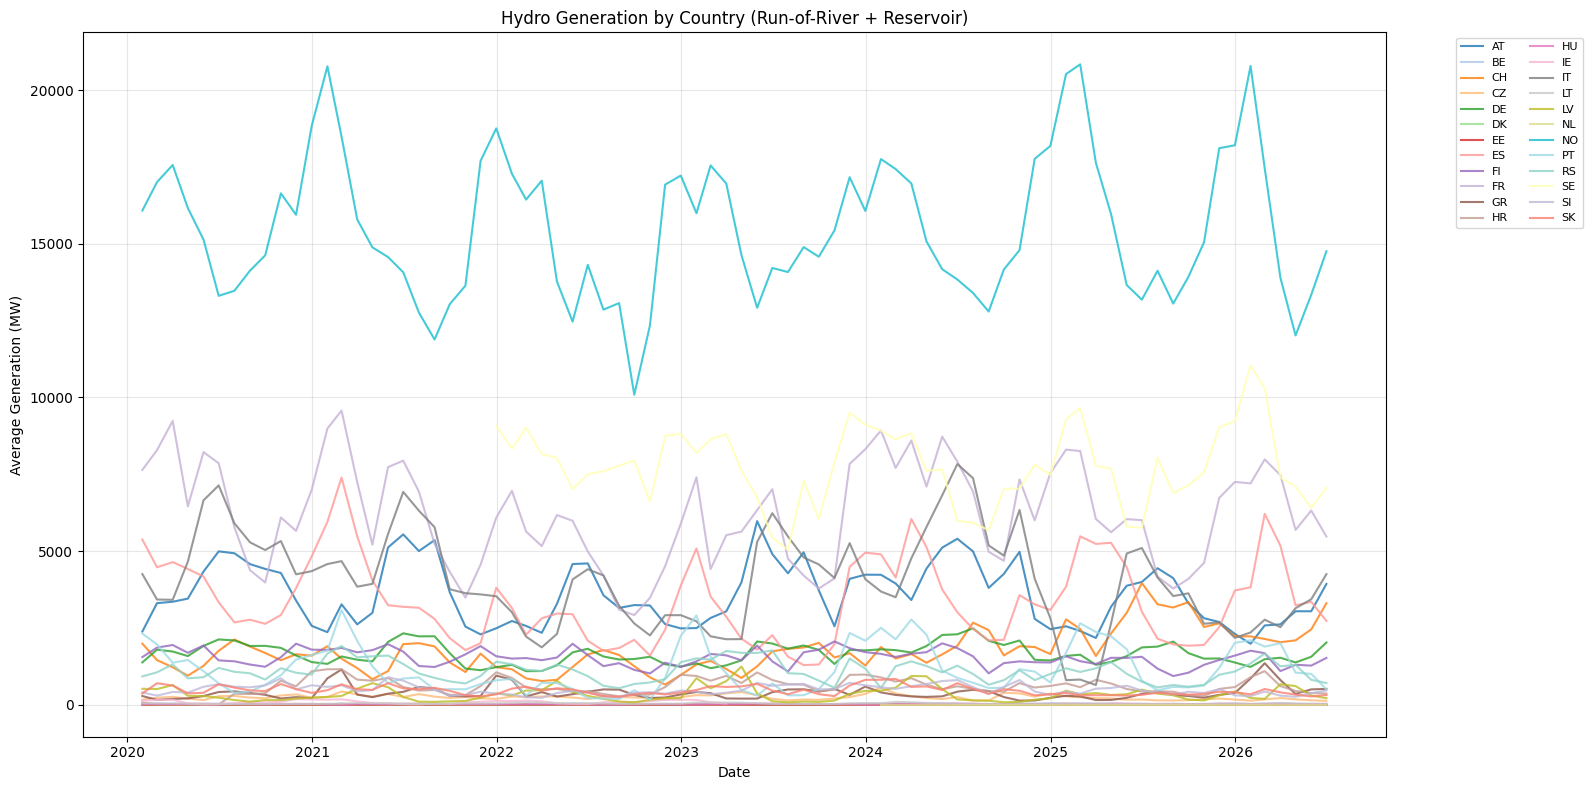

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Assign consistent colors to all countries
all_countries = sorted(df_hydro.columns)
_colors = (plt.cm.tab20.colors[:20] + plt.cm.Set3.colors[:7])
country_colors = {country: _colors[i % len(_colors)] for i, country in enumerate(all_countries)}

# Monthly average hydro generation
monthly_hydro = df_hydro.resample('ME').mean()
for country in sorted(monthly_hydro.columns):
    ax.plot(monthly_hydro.index, monthly_hydro[country], label=country, alpha=0.8, color=country_colors[country])
ax.set_xlabel('Date')
ax.set_ylabel('Average Generation (MW)')
ax.set_title('Hydro Generation by Country (Run-of-River + Reservoir)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison with GO Issuances

We compare ENTSO-E actual hydro generation (run-of-river + reservoir, converted to MWh) with GO issuance data from AIB statistics. The GO data is filtered for electricity certificates with hydro as the energy source. Monthly generation is matched to monthly GO issuance by country.

In [12]:
import pandas as pd

path_1 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_1.csv"
df_1 = pd.read_csv(path_1, sep=",")

path_2 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_2.csv"
df_2 = pd.read_csv(path_2, sep=",")

df = pd.concat([df_1, df_2], ignore_index=True)

display(df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


In [13]:
go_df = df.copy()

# Only consider energy carrier electricity for now
go_df = go_df[go_df['energy_carrier'].str.contains('Electricity')]

# Calendar columns
go_df["month"] = go_df["year_month_date"].str.split("-").str[1].astype(int)
go_df["year"] = go_df["year"].astype(int)

go_df = go_df.drop(columns=["year_month_date", "month_name"])

# Classification columns
go_df['country_code'] = go_df['domain_name'].str.split(' ').str[0].astype(str)
go_df['energy_source_category'] = go_df['energy_source_level1'].astype(str)
go_df['energy_source'] = go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

go_df = go_df.drop(columns=['domain_name', 'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'])

# Columns reordering
go_df = go_df[['year', 'month', 'country_code', 'energy_source_category', 'energy_source'] + go_df.columns[1:11].tolist()]

# Remove incomplete last month data
go_df = go_df[(go_df['year'] >= 2020) & ~((go_df['year'] == 2026) & (go_df['month'] == 4))]

display(go_df)

,year,month,country_code,energy_source_category,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025,3,PT,Renewable,Biomass,0,0,0,0,0,0,1134,0,0,0
1,2026,3,CZ,Renewable,Biomass,0,0,0,1918,0,0,1918,0,0,0
2,2025,5,FR,Renewable,Biomass,5529,0,0,0,0,0,0,0,0,0
3,2023,3,CZ,Renewable,Wind,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024,3,FR,Renewable,Biomass,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114133,2021,11,DK,Renewable,Marine,46596,0,190,0,4673,1024,11840,233,0,0
114135,2022,12,IT,Renewable,Biomass,147307,0,128702,0,0,7254,263060,154040,10722,0
114137,2020,4,AT,Renewable,Biomass,0,0,0,357,0,0,0,0,0,0
114138,2022,2,AT,Renewable,Biomass,0,0,0,0,0,0,0,0,14626,0


In [14]:
# Filter GO data for hydro only
hydro_go = go_df[go_df['energy_source'] == 'Marine'].copy()

# Monthly GO issuance (MWh) by country
go_issued = hydro_go.groupby(['year', 'month', 'country_code'])['production_date_issue'].sum().reset_index()
go_issued.columns = ['year', 'month', 'country_code', 'go_issued_mwh']
go_issued['date'] = pd.to_datetime(go_issued[['year', 'month']].assign(day=1))

# Monthly ENTSO-E generation (MW hourly -> MWh by summing hourly values)
monthly_gen_mwh = df_hydro.resample('ME').sum()  # sum of hourly MW = MWh

# Reshape to long format for comparison
gen_long = monthly_gen_mwh.reset_index().melt(id_vars='ValueDateUTC', var_name='country_code', value_name='entsoe_mwh')
gen_long['year'] = gen_long['ValueDateUTC'].dt.year
gen_long['month'] = gen_long['ValueDateUTC'].dt.month

# Merge GO issuance with ENTSO-E generation
comparison = gen_long.merge(go_issued, on=['year', 'month', 'country_code'], how='outer')
comparison['date'] = pd.to_datetime(comparison[['year', 'month']].assign(day=1))
comparison = comparison.sort_values(['country_code', 'date'])

# GO issuance rate (% of generation that got GOs issued)
entsoe_safe = comparison['entsoe_mwh'].where(comparison['entsoe_mwh'] != 0)
comparison['go_rate'] = comparison['go_issued_mwh'] / entsoe_safe * 100

display(comparison[['date', 'country_code', 'entsoe_mwh', 'go_issued_mwh', 'go_rate']].dropna(subset=['entsoe_mwh', 'go_issued_mwh']))

,date,country_code,entsoe_mwh,go_issued_mwh,go_rate
0,2020-01-01,AT,1771980.75,2384778.0,134.582613
29,2020-02-01,AT,2300839.75,2591549.0,112.634919
58,2020-03-01,AT,2493679.0,2915781.0,116.926878
87,2020-04-01,AT,2486006.25,2893846.0,116.405419
116,2020-05-01,AT,3224787.25,3667660.0,113.733394
...,...,...,...,...,...
2060,2025-11-01,SK,302523.2,283123.0,93.587203
2088,2025-12-01,SK,302984.8,277367.0,91.544856
2117,2026-01-01,SK,252052.5,233194.0,92.518027
2146,2026-02-01,SK,343382.4,322197.0,93.830377


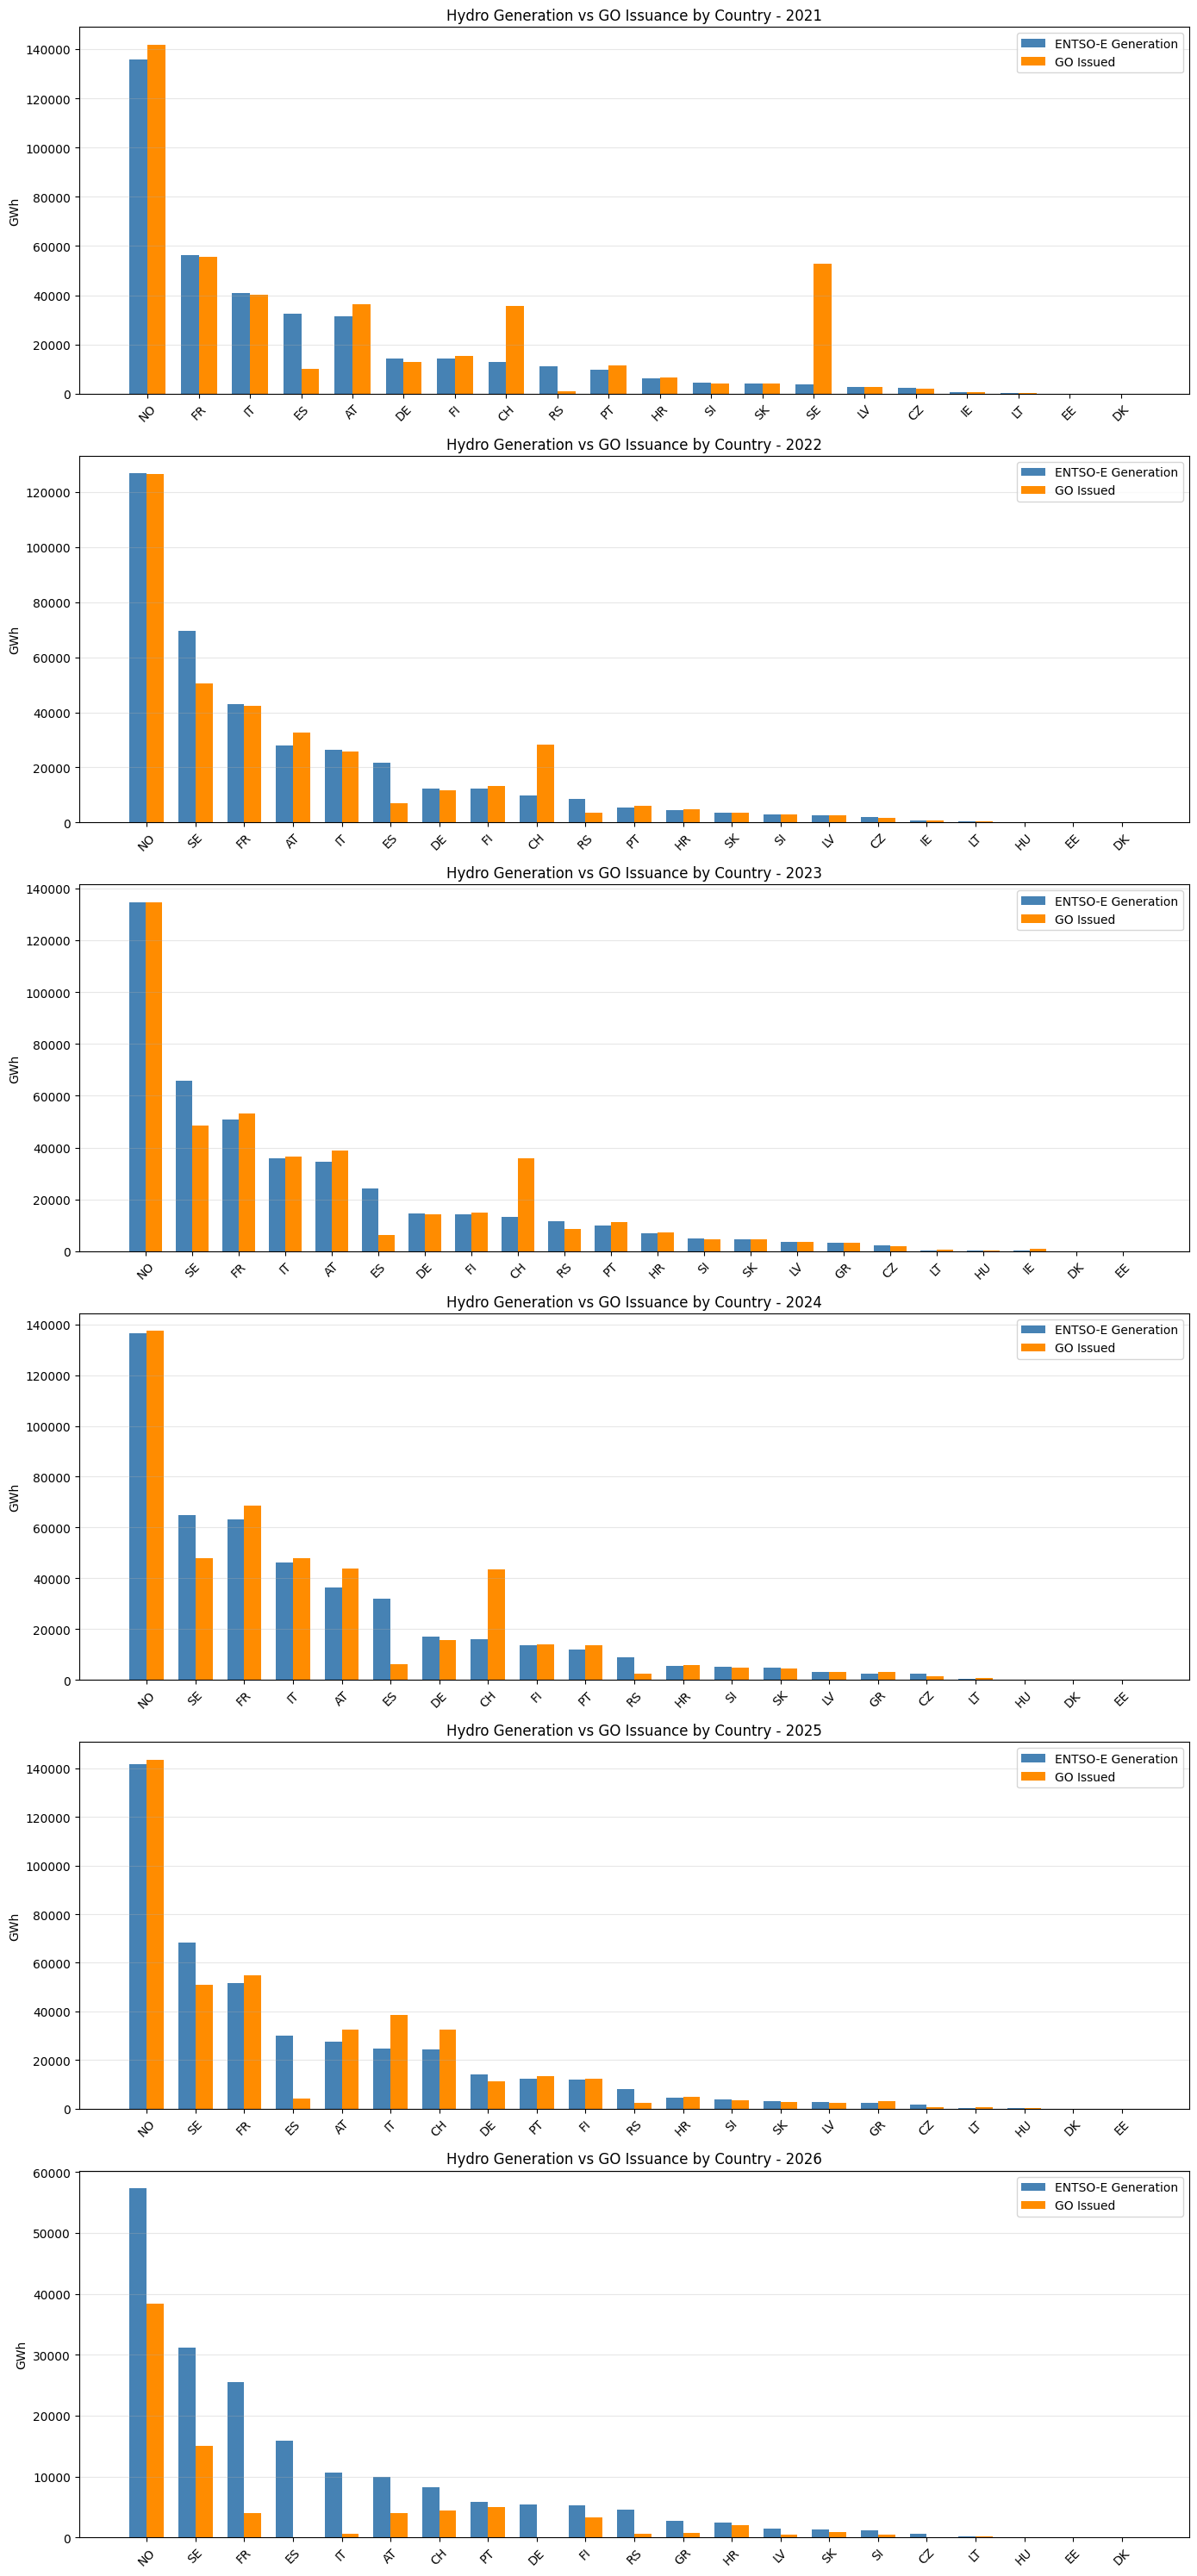

In [15]:
# Plot comparison: annual totals by country
annual = comparison.groupby(['country_code', comparison['date'].dt.year]).agg(
    entsoe_gwh=('entsoe_mwh', lambda x: x.sum() / 1e3),
    go_issued_gwh=('go_issued_mwh', lambda x: x.sum() / 1e3)
).reset_index()
annual.columns = ['country_code', 'year', 'entsoe_gwh', 'go_issued_gwh']

# Filter to countries present in both datasets and year 2021+
annual = annual[(annual['entsoe_gwh'] > 0) & (annual['go_issued_gwh'] > 0) & (annual['year'] >= 2021)]

# Plot per year
years = sorted(annual['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)))

for i, year in enumerate(years):
    ax = axes[i] if len(years) > 1 else axes
    year_data = annual[annual['year'] == year].sort_values('entsoe_gwh', ascending=False)
    
    x = range(len(year_data))
    width = 0.35
    ax.bar([p - width/2 for p in x], year_data['entsoe_gwh'], width, label='ENTSO-E Generation', color='steelblue')
    ax.bar([p + width/2 for p in x], year_data['go_issued_gwh'], width, label='GO Issued', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(year_data['country_code'], rotation=45)
    ax.set_ylabel('GWh')
    ax.set_title(f'Hydro Generation vs GO Issuance by Country - {year}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Pending GO Issuance by Production Year

For each country, we compute a settled GO factor (sum of GOs issued / sum of ENTSO-E generation) over 2022–2024 — production years fully past the 12-month issuance window. Applying this benchmark to each year's ENTSO-E generation gives the expected total GO issuance per year; the difference vs. actual `production_date_issue` is the pending volume. By construction, 2022–2024 net to ~0; 2021 reflects how that year's coverage compares to the benchmark; 2025–2026 reflect timing-related pending issuance still within the window.

In [16]:
# Pending GO issuance per production year
# Approach: use 2022-2024 as "settled benchmark" years (fully past the 12-month issuance window).
# For each country, compute the aggregate GO factor (sum of production_date_issue / sum of ENTSO-E gen)
# over those years. Apply this factor to each year's ENTSO-E generation to get expected total GOs.
# Pending = expected - actual production_date_issue (clipped at 0, at the year aggregate).
# Note: by construction 2022-2024 net to ~0 pending. 2021 reflects how that year's coverage compares
# to the 2022-2024 average. 2025-2026 reflect timing-related pending issuance still within the window.
# Exclude SE 2021 due to presumed ENTSO-E reporting error (anomalously low generation).

historical = annual[(annual['year'] >= 2021) & (annual['year'] <= 2025)].copy()
historical = historical[~((historical['country_code'] == 'SE') & (historical['year'] == 2021))]

settled_factors = historical[historical['year'].between(2022, 2024)].groupby('country_code').apply(
    lambda g: g['go_issued_gwh'].sum() / g['entsoe_gwh'].sum()
)

print("Settled Hydro GO Issuance Factor by Country (2022-2024 aggregate)")
print("Factor = sum(GO Issued) / sum(ENTSO-E Generation)")
print("=" * 65)
display(settled_factors.round(3).rename('settled_factor').to_frame())

pending_per_year = annual.copy()
pending_per_year['settled_factor'] = pending_per_year['country_code'].map(settled_factors)
pending_per_year['expected_go_gwh'] = pending_per_year['entsoe_gwh'] * pending_per_year['settled_factor']

# Aggregate first, then clip at the year level so countries with issued > expected
# offset countries with issued < expected, rather than being floored to zero per-country.
pending_by_year = pending_per_year.groupby('year').agg(
    entsoe_gwh=('entsoe_gwh', 'sum'),
    expected_gwh=('expected_go_gwh', 'sum'),
    issued_gwh=('go_issued_gwh', 'sum'),
).round(0)
pending_by_year['pending_gwh'] = (pending_by_year['expected_gwh'] - pending_by_year['issued_gwh']).clip(lower=0)
pending_by_year['pct_issued'] = (pending_by_year['issued_gwh'] / pending_by_year['expected_gwh'] * 100).round(1)

print(f"\nPending Hydro GO issuance by production year")
print(f"(Benchmark: 2022-2024 settled GO factor per country, applied to each year's ENTSO-E generation)")
print("=" * 75)
display(pending_by_year)

Settled Hydro GO Issuance Factor by Country (2022-2024 aggregate)
Factor = sum(GO Issued) / sum(ENTSO-E Generation)


/var/folders/9z/lz_ys39936g9hjq8wmdvgm080000gn/T/ipykernel_5412/1698118054.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  settled_factors = historical[historical['year'].between(2022, 2024)].groupby('country_code').apply(


,settled_factor
country_code,
AT,1.167
CH,2.746
CZ,0.707
DE,0.952
DK,1.174
EE,2.058
ES,0.252
FI,1.050
FR,1.046



Pending Hydro GO issuance by production year
(Benchmark: 2022-2024 settled GO factor per country, applied to each year's ENTSO-E generation)


,entsoe_gwh,expected_gwh,issued_gwh,pending_gwh,pct_issued
year,,,,,
2021,385059.0,387102.0,434256.0,0.0,112.2
2022,381802.0,368498.0,365094.0,3404.0,99.1
2023,435533.0,427535.0,430176.0,0.0,100.6
2024,471134.0,465311.0,466075.0,0.0,100.2
2025,434073.0,441037.0,414953.0,26084.0,94.1
2026,189998.0,186088.0,80392.0,105696.0,43.2


## Conclusion

The comparison between ENTSO-E hydro generation (run-of-river + reservoir) and GO issuance across 24 AIB electricity scheme group countries reveals several key patterns:

**Data coverage:** We successfully collected hydro production curves for 24 out of 27 countries in the AIB electricity scheme group. Only Cyprus (CY), Iceland (IS), and Luxembourg (LU) lack data — the first two have negligible hydro capacity and LU's production is minimal.

**Norway (NO):** The largest hydro producer (~135 TWh/year), with a GO factor of ~1.01 — near-perfect 1:1 alignment between generation and GO issuance. This reflects a mature, fully-certified market and Norway's role as Europe's largest GO exporter.

**Sweden (SE):** The second-largest producer (~67 TWh/year), with a GO factor of ~0.74. This persistent gap suggests a portion of Swedish hydro does not receive GOs — possibly older plants or capacity that has opted out of certification.

**France (FR):** A major hydro market (~53 TWh/year) with a GO factor of ~1.03, indicating close alignment between generation and issuance.

**Italy (IT) and Austria (AT):** Both show GO factors above 1.0 (IT ~1.12, AT ~1.17), meaning GO issuance slightly exceeds measured ENTSO-E generation. This could reflect timing differences, data granularity, or additional capacity not fully captured by ENTSO-E.

**Switzerland (CH):** Exhibits a very high GO factor (~2.47), suggesting that Switzerland issues GOs well in excess of ENTSO-E-reported generation. This likely reflects that ENTSO-E data captures only a subset of Swiss hydro production, or that Swiss GOs cover generation from bilateral arrangements not fully visible in transparency data.

**Spain (ES):** Despite being a significant hydro producer (~28 TWh/year), Spain has a very low GO factor (~0.25), indicating that only about a quarter of hydro generation receives GOs. This may reflect limited participation in the GO scheme or a preference for domestic disclosure mechanisms.

**Germany (DE):** Shows a high GO factor (~1.93) relative to ENTSO-E data, likely because the ENTSO-E curves only cover a subset of German TSO regions and undercount total hydro.

**Pending GO issuance — hydro is the outlier:** Unlike wind and solar, hydro shows meaningful pending issuance from 2025 production even by mid-2026. Two factors drive this:

1. *Strategic timing of issuance.* Nordic hydro GOs (NO + SE dominate the volumes) are highly liquid with strong seasonal price patterns. Producers like Statkraft, Fortum and Vattenfall routinely delay issuance within the AIB 12-month window — batches are often issued 6–11 months after production to align with year-end disclosure cycles, retail compliance windows, or favorable price levels. This is a well-known structural feature of the Nordic hydro segment.
2. *Less standardized PPA settlement.* Hydro is less typically tied to monthly merchant PPA settlement than wind or solar, removing the operational pressure to issue immediately.

The absolute pending volume should be read with caution: countries with GO factors >1 (CH, DE, AT, IT) inflate the projected "expected" GOs because the benchmark factor is partly compensating for ENTSO-E undercoverage rather than reflecting true issuance behaviour. The *direction* (residual 2025 pending) is robust; the *magnitude* is an upper bound.

**Pumped storage exclusion:** By excluding pumped storage generation, we focus on the portion of hydro output that is fully GO-eligible. Countries with significant pumped storage would show higher total hydro production if included, but the GO comparison would be less meaningful since only natural inflow qualifies for certification.
